## Uticaj predobrade i kvaliteta tekstualnih podataka na performanse klasifikacionih modela: Analiza IMDB recenzija filmova 


### Uvod

U ovom radu analizira se uticaj kvaliteta i predobrade tekstualnih podataka na klasifikaciju sentimenta filmskih recenzija. Koristi se IMDB skup podataka sa pozitivnim i negativnim recenzijama, pri čemu se posmatraju karakteristike kao što su dužina teksta, veličina vokabulara, leksička raznovrsnost i prisustvo šuma.

Fokus analize je na:
- osnovnim pokazateljima kvaliteta teksta, kao što su dužina dokumenata, veličina vokabulara, leksička raznovrsnost i prisustvo šuma,
- tehnikama predobrade, uključujući čišćenje teksta, normalizaciju, uklanjanje stop-reči i lematizaciju,
- uticaju tih koraka na reprezentaciju teksta i uspešnost klasifikacionih modela.


In [207]:
import pandas as pd
import numpy as np
import re
import html
import unicodedata

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS


In [208]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Učitavanje i osnovni pregled podataka

U ovoj sekciji učitava se skup podataka iz CSV fajla i vrši se osnovni pregled:
- dimenzije skupa podataka,
- nazivi i tipovi kolona,
- primeri redova,
- osnovne statističke karakteristike numeričkih obeležja.

Ovaj korak omogućava bolje razumevanje strukture podataka i identifikaciju potencijalnih problema, kao što su nedostajuće ili nekonzistentne vrednosti.

In [209]:
data_path = "data/IMDB_Dataset.csv"

df = pd.read_csv(data_path)

df.shape

(50000, 2)

In [210]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [211]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [212]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [213]:
df.dtypes

review       str
sentiment    str
dtype: object

U nastavku se proverava broj nedostajućih vrednosti po kolonama. Ovaj korak pokazuje da li postoje vrednosti koje je potrebno ukloniti ili popuniti pre dalje analize.

In [214]:
missing_values = df.isna().sum().to_frame("broj_nedostajucih_vrednosti")

missing_values

,broj_nedostajucih_vrednosti
review,0
sentiment,0


## Analiza kvaliteta tekstualnih podataka

Kod tekstualnih podataka kvalitet se ne posmatra samo kroz nedostajuće vrednosti i duplikate, već i kroz osobine samog teksta. U ovoj sekciji analiziraju se balans klasa, dužina recenzija, broj reči, veličina vokabulara, leksička raznovrsnost i prisustvo osnovnog šuma u tekstu.

In [215]:
df['length'] = df['review'].apply(lambda x: len(x.split()))

df['length'].describe()

count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: length, dtype: float64

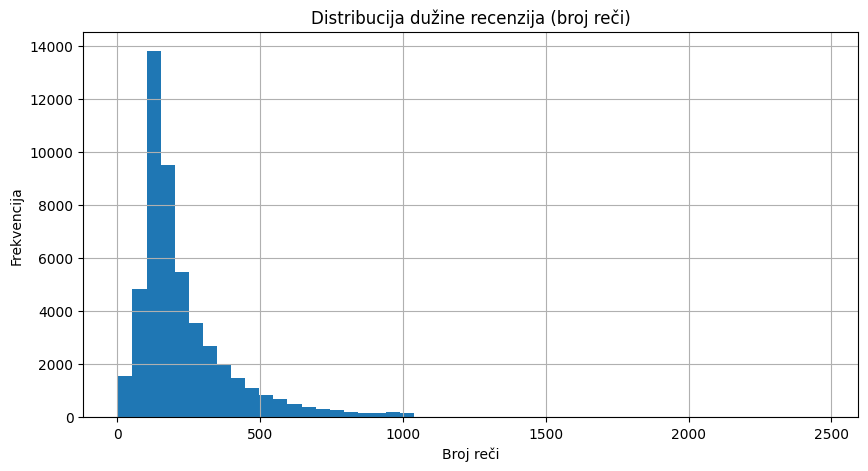

In [216]:
plt.figure()
plt.hist(df['length'], bins=50)
plt.title("Distribucija dužine recenzija (broj reči)")
plt.xlabel("Broj reči")
plt.ylabel("Frekvencija")
plt.show()

In [217]:
quality_summary = pd.DataFrame({
    "broj_redova": [len(df)],
    "broj_kolona": [df.shape[1]],
    "nedostajuce_recenzije": [df["review"].isna().sum()],
    "nedostajuce_oznake": [df["sentiment"].isna().sum()],
    "duplikati": [df.duplicated().sum()],
    "jedinstvene_recenzije": [df["review"].nunique()]
})

quality_summary

,broj_redova,broj_kolona,nedostajuce_recenzije,nedostajuce_oznake,duplikati,jedinstvene_recenzije
0,50000,3,0,0,418,49582


In [218]:
class_distribution = df["sentiment"].value_counts().to_frame("broj")
class_distribution["procenat"] = (class_distribution["broj"] / len(df) * 100).round(2)

class_distribution

,broj,procenat
sentiment,,
positive,25000,50.0
negative,25000,50.0


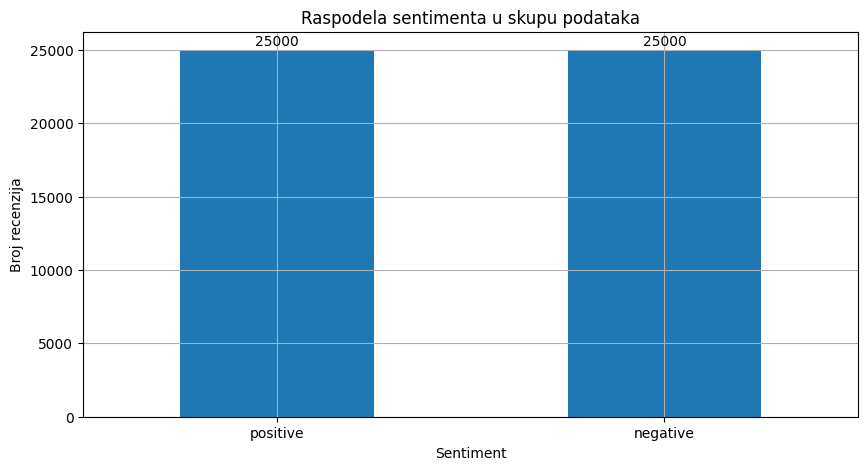

In [219]:
class_distribution["broj"].plot(kind="bar")
plt.title("Raspodela sentimenta u skupu podataka")
plt.xlabel("Sentiment")
plt.ylabel("Broj recenzija")
plt.xticks(rotation=0)

for index, value in enumerate(class_distribution["broj"]):
    plt.text(index, value + 300, str(value), ha="center")

plt.show()

### Dužina teksta i leksička raznovrsnost

Dužina dokumenta i broj različitih reči važni su pokazatelji kvaliteta teksta. Veoma kratke recenzije mogu sadržati premalo informacija, dok veoma dugačke recenzije mogu uneti dodatni šum. Leksička raznovrsnost računa se kao odnos broja jedinstvenih reči i ukupnog broja reči u recenziji.

In [220]:
tokens = df["review"].str.lower().str.findall(r"\b[a-zA-Z]+\b")

df["char_count"] = df["review"].str.len()
df["word_count"] = tokens.apply(len)
df["unique_word_count"] = tokens.apply(lambda words: len(set(words)))
df["lexical_diversity"] = df["unique_word_count"] / df["word_count"]

df[["char_count", "word_count", "unique_word_count", "lexical_diversity"]].describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,50000.0,1309.431020,989.728014,32.00000,699.000000,970.000000,1590.250000,13704.0
word_count,50000.0,237.869060,176.343291,6.00000,130.000000,178.000000,289.000000,2510.0
unique_word_count,50000.0,139.137580,79.621181,5.00000,88.000000,115.000000,169.000000,972.0
lexical_diversity,50000.0,0.637399,0.093927,0.04186,0.575941,0.636986,0.696721,1.0


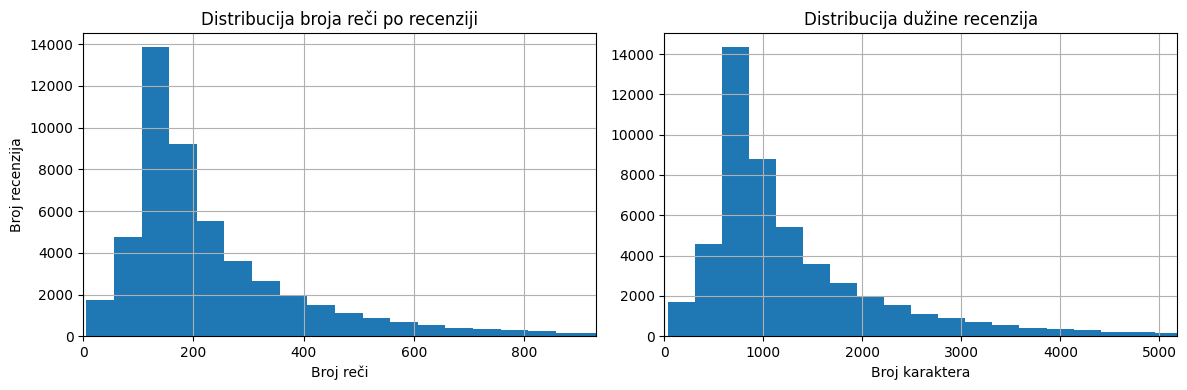

In [221]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

word_limit = df["word_count"].quantile(0.99)
char_limit = df["char_count"].quantile(0.99)

axes[0].hist(df["word_count"], bins=50)
axes[0].set_title("Distribucija broja reči po recenziji")
axes[0].set_xlabel("Broj reči")
axes[0].set_ylabel("Broj recenzija")
axes[0].set_xlim(0, word_limit)


axes[1].hist(df["char_count"], bins=50)
axes[1].set_title("Distribucija dužine recenzija")
axes[1].set_xlabel("Broj karaktera")
axes[1].set_xlim(0, char_limit)

plt.tight_layout()
plt.show()

In [222]:
df.groupby("sentiment")[["char_count", "word_count", "unique_word_count", "lexical_diversity"]].mean().round(2)

,char_count,word_count,unique_word_count,lexical_diversity
sentiment,,,,
negative,1294.06,236.46,139.23,0.64
positive,1324.80,239.28,139.05,0.64


### Vokabular i šum u tekstu

Veličina vokabulara pokazuje koliko različitih reči postoji u celom skupu podataka. Kod recenzija se dodatno proverava prisustvo HTML oznaka, brojeva, velikih slova i karaktera koji nisu standardna slova ili brojevi, jer takvi elementi mogu uticati na kasniju tokenizaciju i vektorizaciju teksta.

In [223]:
for i in range(5):
    print(f"Primer {i+1}:\n")
    print(df['review'].iloc[i])
    print("\n" + "-"*80 + "\n")

Primer 1:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due

In [224]:
all_tokens = tokens.explode()
total_tokens = all_tokens.shape[0]
vocabulary_size = all_tokens.nunique()

vocabulary_summary = pd.DataFrame({
    "ukupan_broj_tokena": [total_tokens],
    "velicina_vokabulara": [vocabulary_size],
    "leksicka_raznovrsnost_korpusa": [vocabulary_size / total_tokens]
})

vocabulary_summary

,ukupan_broj_tokena,velicina_vokabulara,leksicka_raznovrsnost_korpusa
0,11893453,98751,0.008303


In [225]:
# <br />
html_noise_count = df["review"].str.contains(r"<br\s*/?>", regex=True, case=False).sum()

# cifre
digit_noise_count = df["review"].str.contains(r"\d", regex=True).sum()

# specijalni znakovi
special_char_count = df["review"].str.contains(r"[^a-zA-Z0-9\s]", regex=True).sum()

print("Broj recenzija sa HTML tagovima:", html_noise_count)
print("Broj recenzija sa ciframa:", digit_noise_count)
print("Broj recenzija sa specijalnim karakterima:", special_char_count)

Broj recenzija sa HTML tagovima: 29200
Broj recenzija sa ciframa: 28005
Broj recenzija sa specijalnim karakterima: 49996


In [226]:
noise_summary = pd.DataFrame({
    "html_tagovi": [df["review"].str.contains(r"<.*?>", regex=True).mean() * 100],
    "brojevi": [df["review"].str.contains(r"\d", regex=True).mean() * 100],
    "vise_velikih_slova": [df["review"].str.contains(r"[A-Z]{3,}", regex=True).mean() * 100],
    "specijalni_karakteri": [df["review"].str.contains(r"[^a-zA-Z0-9\s.,!?;:'\"-]", regex=True).mean() * 100]
}).round(2)

noise_summary

,html_tagovi,brojevi,vise_velikih_slova,specijalni_karakteri
0,58.4,56.01,39.9,80.88


### Normalizacija teksta

Normalizacija smanjuje broj različitih oblika istih reči. Na primer, reči `Movie`, `movie` i `MOVIE` posle pretvaranja u mala slova postaju isti token. Uklanjanje HTML oznaka je važno jer IMDB recenzije sadrže oznake kao što je `<br />`, koje ne nose značenje za analizu sentimenta.

In [227]:
def normalize_text(text):
    text = html.unescape(text)
    text = unicodedata.normalize("NFKC", text)
    text = re.sub(r"<.*?>", " ", text)
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [228]:
df["review_normalized"] = df["review"].apply(normalize_text)

df[["review", "review_normalized"]].head()

,review,review_normalized
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


### Tokenizacija

U radu se koristi tokenizacija na nivou reči, jer je pogodna za BoW i TF-IDF. Tokenizacija na nivou rečenica korisna je kada se analizira struktura teksta, dok se subword tokenizacija najčešće koristi kod transformer modela kao što je BERT.


### Uklanjanje stop-reči

Stop-reči su česte reči u jeziku (npr. "the", "and", "is") koje obično ne nose značajnu semantičku informaciju za zadatak klasifikacije.

In [229]:
def remove_stop_words(text):
    words = text.split()
    words = [word for word in words if word not in ENGLISH_STOP_WORDS]
    return " ".join(words)

In [230]:
df["review_no_stopwords"] = df["review_normalized"].apply(remove_stop_words)

df[["review_normalized", "review_no_stopwords"]].head()

,review_normalized,review_no_stopwords
0,one of the other reviewers has mentioned that ...,reviewers mentioned watching just 1 oz episode...
1,a wonderful little production the filming tech...,wonderful little production filming technique ...
2,i thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...
3,basically there s a family where a little boy ...,basically s family little boy jake thinks s zo...
4,petter mattei s love in the time of money is a...,petter mattei s love time money visually stunn...


### Poređenje teksta pre i posle predobrade

Poređenjem osnovnih statistika može se videti kako predobrada menja tekst. Uklanjanje znakova i stop-reči najčešće smanjuje ukupan broj tokena i veličinu vokabulara, što može pomoći klasičnim modelima kao što su Bag-of-Words i TF-IDF.

In [231]:
def text_statistics(text_series):
    tokenized = text_series.str.findall(r"\b[a-z0-9]+\b")
    word_counts = tokenized.apply(len)
    all_words = tokenized.explode()
    vocabulary_size = all_words.nunique()
    total_words = word_counts.sum()

    return pd.Series({
        "prosecna_duzina_karakteri": text_series.str.len().mean(),
        "prosecan_broj_reci": word_counts.mean(),
        "ukupan_broj_tokena": total_words,
        "velicina_vokabulara": vocabulary_size,
        "leksicka_raznovrsnost": vocabulary_size / total_words
    })


preprocessing_comparison = pd.DataFrame({
    "originalni_tekst": text_statistics(df["review"]),
    "normalizovan_tekst": text_statistics(df["review_normalized"]),
    "bez_stop_reci": text_statistics(df["review_no_stopwords"])
}).T

preprocessing_comparison.round(4)

,prosecna_duzina_karakteri,prosecan_broj_reci,ukupan_broj_tokena,velicina_vokabulara,leksicka_raznovrsnost
originalni_tekst,1309.4310,208.7908,10439541.0,63113.0,0.0060
normalizovan_tekst,1252.9463,235.5602,11778011.0,101241.0,0.0086
bez_stop_reci,755.6332,111.9134,5595670.0,100927.0,0.0180


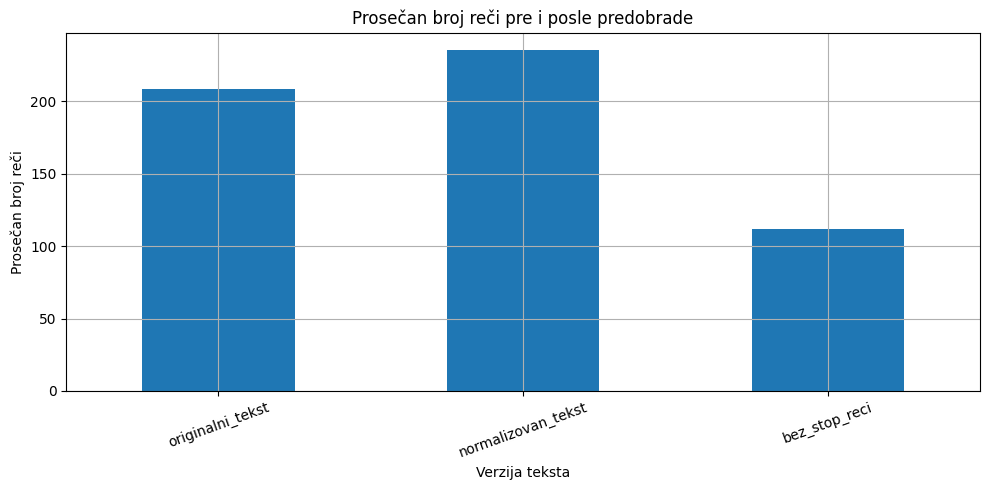

In [232]:
preprocessing_comparison["prosecan_broj_reci"].plot(kind="bar")
plt.title("Prosečan broj reči pre i posle predobrade")
plt.xlabel("Verzija teksta")
plt.ylabel("Prosečan broj reči")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Lematizacija i stemming

Stemming i lematizacija su dodatni postupci svođenja reči na osnovniji oblik. Stemming grubo skraćuje reči, dok lematizacija koristi gramatičko značenje reči i obično daje pravilniji osnovni oblik. U ovom praktičnom delu koristi se osnovna normalizacija i uklanjanje stop-reči i lematizacija, jer su dovoljni za poređenje uticaja predobrade kod BoW i TF-IDF modela.


In [233]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/natalijapavlovic/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/natalijapavlovic/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/natalijapavlovic/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/natalijapavlovic/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/natalijapavlovic/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/natalijapavlovic/nltk_data...
[nltk_data]   Package omw-1.4 is alre

In [234]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
example_words = ["running", "studies", "better", "movies"]

pd.DataFrame({
    "rec": example_words,
    "stemming": [stemmer.stem(word) for word in example_words],
    "lemmatizacija": [lemmatizer.lemmatize(word) for word in example_words]
})


,rec,stemming,lemmatizacija
0,running,run,running
1,studies,studi,study
2,better,better,better
3,movies,movi,movie


In [235]:
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith("J"):
        return wordnet.ADJ
    elif treebank_tag.startswith("V"):
        return wordnet.VERB
    elif treebank_tag.startswith("N"):
        return wordnet.NOUN
    elif treebank_tag.startswith("R"):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [236]:
def lemmatize_text(text):
    tokens = word_tokenize(text)
    tagged_tokens = pos_tag(tokens)
    lemmatized_words = [
        lemmatizer.lemmatize(word, get_wordnet_pos(tag))
        for word, tag in tagged_tokens
    ]
    return " ".join(lemmatized_words)

In [237]:
df["review_lemmatized"] = df["review_no_stopwords"].apply(lemmatize_text)

df[["review_no_stopwords", "review_lemmatized"]].head()

,review_no_stopwords,review_lemmatized
0,reviewers mentioned watching just 1 oz episode...,reviewer mention watch just 1 oz episode ll ho...
1,wonderful little production filming technique ...,wonderful little production film technique una...
2,thought wonderful way spend time hot summer we...,think wonderful way spend time hot summer week...
3,basically s family little boy jake thinks s zo...,basically s family little boy jake think s zom...
4,petter mattei s love time money visually stunn...,petter mattei s love time money visually stunn...


In [238]:
preprocessing_comparison_extended = pd.DataFrame({
    "originalni_tekst": text_statistics(df["review"]),
    "normalizovan_tekst": text_statistics(df["review_normalized"]),
    "bez_stop_reci": text_statistics(df["review_no_stopwords"]),
    "lematizovan_tekst": text_statistics(df["review_lemmatized"])
}).T

preprocessing_comparison_extended.round(4)

,prosecna_duzina_karakteri,prosecan_broj_reci,ukupan_broj_tokena,velicina_vokabulara,leksicka_raznovrsnost
originalni_tekst,1309.4310,208.7908,10439541.0,63113.0,0.0060
normalizovan_tekst,1252.9463,235.5602,11778011.0,101241.0,0.0086
bez_stop_reci,755.6332,111.9134,5595670.0,100927.0,0.0180
lematizovan_tekst,716.8355,111.9355,5596773.0,90371.0,0.0161


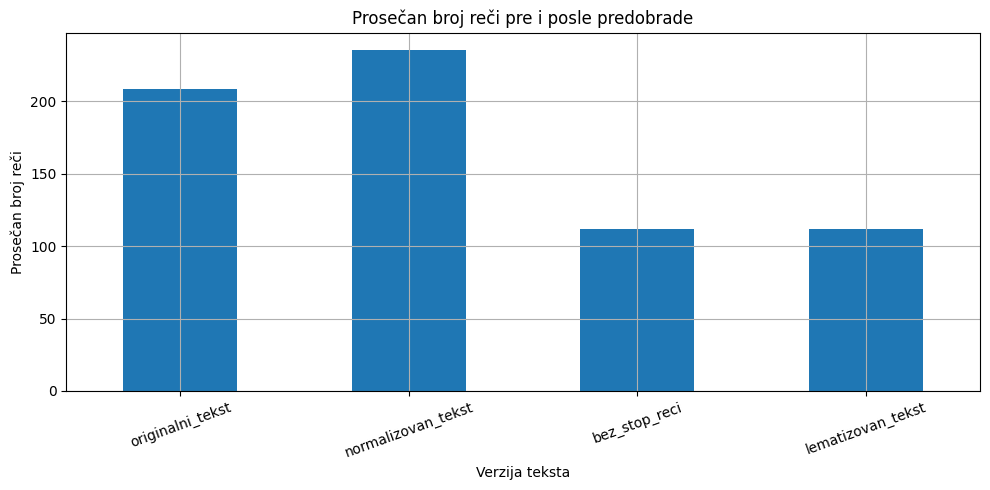

In [239]:
preprocessing_comparison_extended["prosecan_broj_reci"].plot(kind="bar")
plt.title("Prosečan broj reči pre i posle predobrade")
plt.xlabel("Verzija teksta")
plt.ylabel("Prosečan broj reči")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Uticaj predobrade na performanse modela

Biće upoređene sledeće verzije teksta:
- originalni tekst,
- normalizovan tekst,
- tekst bez stop-reči,
- lematizovan tekst.

Za sve eksperimente koristi se ista metoda reprezentacije (TF-IDF) i isti klasifikacioni model (Logistic Regression), kako bi se obezbedilo fer poređenje.

In [240]:
df_model = df.drop_duplicates(subset=["review", "sentiment"]).copy()

X = df_model["review"]
y = df_model["sentiment"]

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [241]:
def evaluate_model(train_text, test_text, label=""):
    tfidf = TfidfVectorizer(max_features=5000, stop_words=None)

    X_train_tfidf = tfidf.fit_transform(train_text)
    X_test_tfidf = tfidf.transform(test_text)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== {label} ===")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - {label}")
    plt.show()

    return acc


=== Originalni tekst ===
Accuracy: 0.8894827064636482
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4940
    positive       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



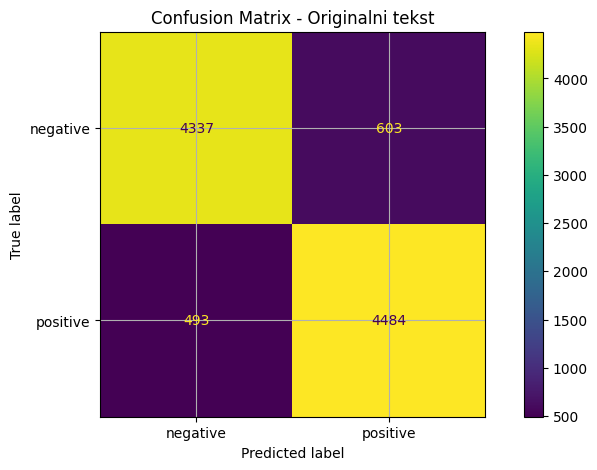


=== Normalizovan tekst ===
Accuracy: 0.8907935867701926
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4940
    positive       0.88      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



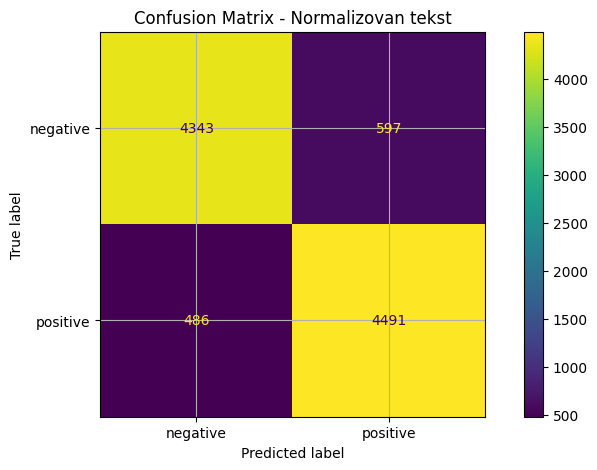

In [242]:
acc_original = evaluate_model(
    X_train_base,
    X_test_base,
    "Originalni tekst"
)

acc_normalized = evaluate_model(
    df_model.loc[X_train_base.index, "review_normalized"],
    df_model.loc[X_test_base.index, "review_normalized"],
    "Normalizovan tekst"
)


=== Bez stop reči ===
Accuracy: 0.8844408591307855
              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4940
    positive       0.87      0.90      0.89      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



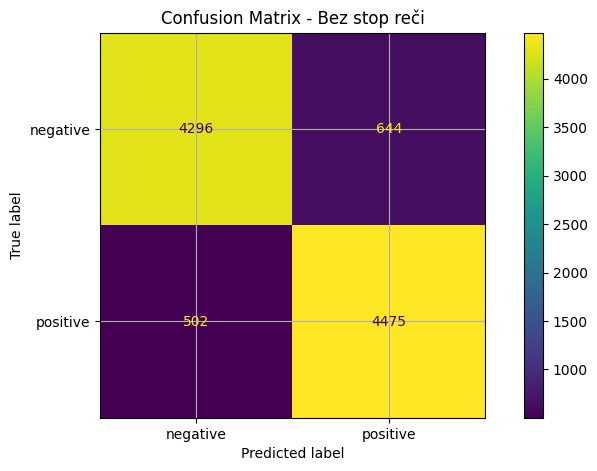


=== Lematizovan tekst ===
Accuracy: 0.8861550872239589
              precision    recall  f1-score   support

    negative       0.90      0.87      0.88      4940
    positive       0.87      0.90      0.89      4977

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



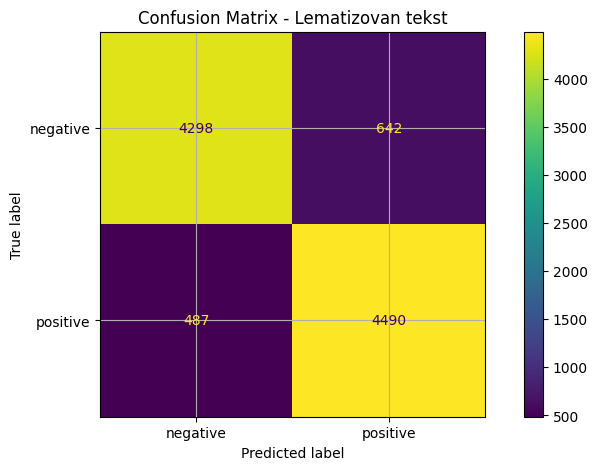

In [243]:
acc_no_stop = evaluate_model(
    df_model.loc[X_train_base.index, "review_no_stopwords"],
    df_model.loc[X_test_base.index, "review_no_stopwords"],
    "Bez stop reči"
)

acc_lemma = evaluate_model(
    df_model.loc[X_train_base.index, "review_lemmatized"],
    df_model.loc[X_test_base.index, "review_lemmatized"],
    "Lematizovan tekst")

### Dodatni model: Multinomial Naive Bayes

In [244]:
def evaluate_nb(train_text, test_text, label=""):
    tfidf = TfidfVectorizer(max_features=5000, stop_words=None)

    X_train_tfidf = tfidf.fit_transform(train_text)
    X_test_tfidf = tfidf.transform(test_text)

    model = MultinomialNB()
    model.fit(X_train_tfidf, y_train)

    y_pred = model.predict(X_test_tfidf)

    acc = accuracy_score(y_test, y_pred)

    print(f"\n=== Naive Bayes - {label} ===")
    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"Confusion Matrix - NB - {label}")
    plt.show()

    return acc


=== Naive Bayes - Originalni tekst ===
Accuracy: 0.8522738731471211
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4940
    positive       0.85      0.86      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



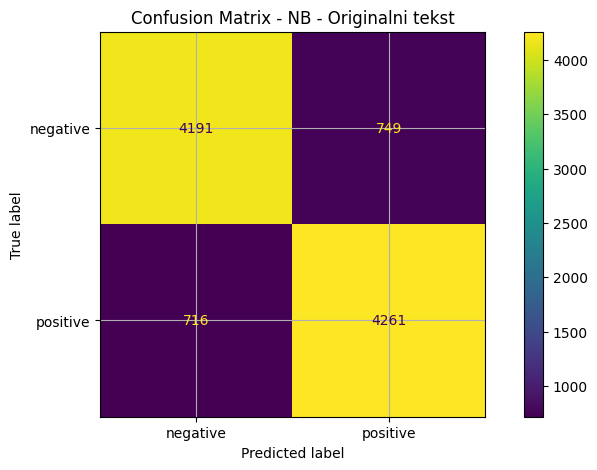


=== Naive Bayes - Normalizovan tekst ===
Accuracy: 0.8520721992538066
              precision    recall  f1-score   support

    negative       0.85      0.85      0.85      4940
    positive       0.85      0.86      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



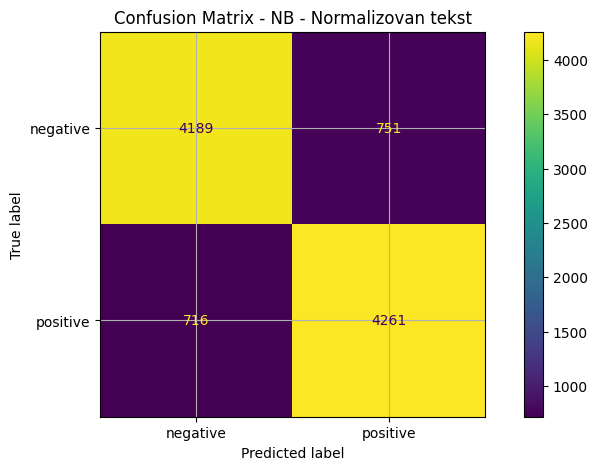

In [245]:
nb_original = evaluate_nb(X_train_base, X_test_base, "Originalni tekst")

nb_normalized = evaluate_nb(
    df_model.loc[X_train_base.index, "review_normalized"],
    df_model.loc[X_test_base.index, "review_normalized"],
    "Normalizovan tekst"
)


=== Naive Bayes - Bez stop-reči ===
Accuracy: 0.8523747100937784
              precision    recall  f1-score   support

    negative       0.86      0.85      0.85      4940
    positive       0.85      0.86      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



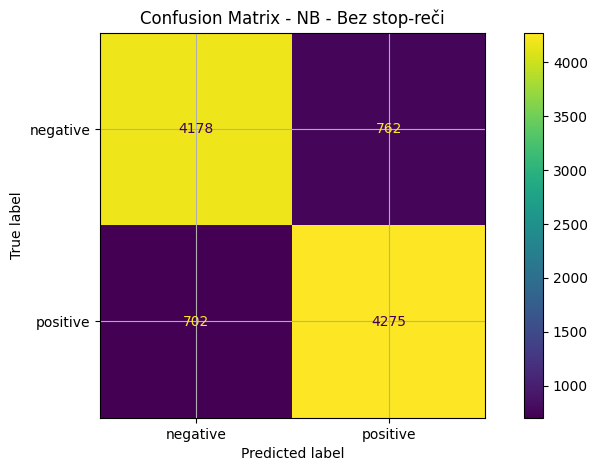


=== Naive Bayes - Lematizovan tekst ===
Accuracy: 0.8506604820006051
              precision    recall  f1-score   support

    negative       0.85      0.84      0.85      4940
    positive       0.85      0.86      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



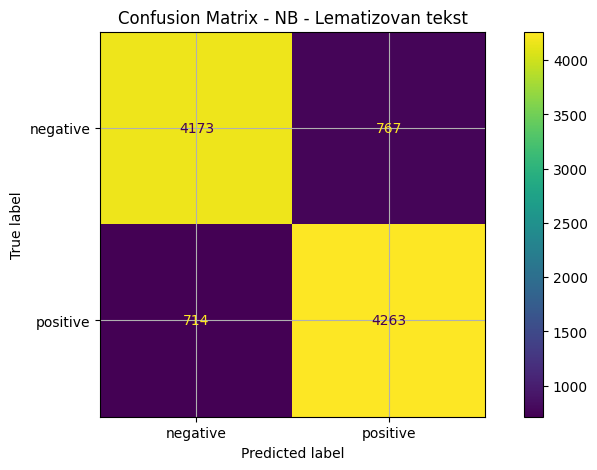

In [246]:
nb_no_stop = evaluate_nb(
    df_model.loc[X_train_base.index, "review_no_stopwords"],
    df_model.loc[X_test_base.index, "review_no_stopwords"],
    "Bez stop-reči"
)

nb_lemma = evaluate_nb(
    df_model.loc[X_train_base.index, "review_lemmatized"],
    df_model.loc[X_test_base.index, "review_lemmatized"],
    "Lematizovan tekst"
)

### BoW i TF-IDF

TF-IDF koristi težine reči, dok BoW računa samo učestalost pojavljivanja. Zato se dodaje kratko poređenje sa CountVectorizer reprezentacijom.


In [247]:
def evaluate_bow_lr(train_text, test_text):
    bow = CountVectorizer(max_features=5000)

    X_train_bow = bow.fit_transform(train_text)
    X_test_bow = bow.transform(test_text)

    model = LogisticRegression(max_iter=1000)
    model.fit(X_train_bow, y_train)

    return accuracy_score(y_test, model.predict(X_test_bow))

bow_results = pd.DataFrame({
    "Model": [
        "BoW - Originalni",
        "BoW - Normalizovan",
        "BoW - Bez stop-reči",
        "BoW - Lematizovan"
    ],
    "Accuracy": [
        evaluate_bow_lr(X_train_base, X_test_base),
        evaluate_bow_lr(
            df_model.loc[X_train_base.index, "review_normalized"],
            df_model.loc[X_test_base.index, "review_normalized"]
        ),
        evaluate_bow_lr(
            df_model.loc[X_train_base.index, "review_no_stopwords"],
            df_model.loc[X_test_base.index, "review_no_stopwords"]
        ),
        evaluate_bow_lr(
            df_model.loc[X_train_base.index, "review_lemmatized"],
            df_model.loc[X_test_base.index, "review_lemmatized"]
        )
    ]
})

bow_results


,Model,Accuracy
0,BoW - Originalni,0.874458
1,BoW - Normalizovan,0.875164
2,BoW - Bez stop-reči,0.871231
3,BoW - Lematizovan,0.872744


## Završna analiza rezultata

Na osnovu dobijenih rezultata može se uočiti da normalizacija blago poboljšava logističku regresiju, dok su razlike kod Naive Bayes modela veoma male. TF-IDF postiže bolje rezultate od BoW reprezentacije, jer daje manju težinu rečima koje su česte u velikom broju dokumenata.

Sa druge strane, uklanjanje stop-reči i lematizacija ne donose jasno poboljšanje tačnosti, što ukazuje da neki uklonjeni oblici reči ipak nose korisnu informaciju za sentiment.


In [248]:
results_df = pd.DataFrame({
    "Model": [
        "Originalni tekst",
        "Normalizovan tekst",
        "Bez stop-reči",
        "Lematizovan tekst"
    ],
    "Accuracy": [
        acc_original,
        acc_normalized,
        acc_no_stop,
        acc_lemma
    ]
})

results_df

,Model,Accuracy
0,Originalni tekst,0.889483
1,Normalizovan tekst,0.890794
2,Bez stop-reči,0.884441
3,Lematizovan tekst,0.886155


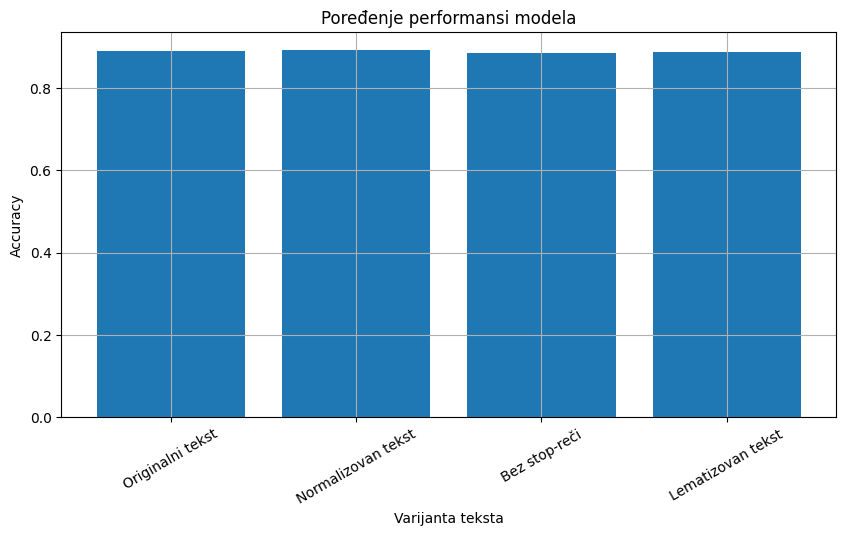

In [249]:
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=30)
plt.title("Poređenje performansi modela")
plt.ylabel("Accuracy")
plt.xlabel("Varijanta teksta")
plt.show()

In [250]:
results_df = pd.DataFrame({
    "Model": [
        "LR - Originalni",
        "LR - Normalizovan",
        "LR - Bez stop-reči",
        "LR - Lematizovan",
        "NB - Originalni",
        "NB - Normalizovan",
        "NB - Bez stop-reči",
        "NB - Lematizovan"
    ],
    "Accuracy": [
        acc_original,
        acc_normalized,
        acc_no_stop,
        acc_lemma,
        nb_original,
        nb_normalized,
        nb_no_stop,
        nb_lemma
    ]
})

results_df

,Model,Accuracy
0,LR - Originalni,0.889483
1,LR - Normalizovan,0.890794
2,LR - Bez stop-reči,0.884441
3,LR - Lematizovan,0.886155
4,NB - Originalni,0.852274
5,NB - Normalizovan,0.852072
6,NB - Bez stop-reči,0.852375
7,NB - Lematizovan,0.850660


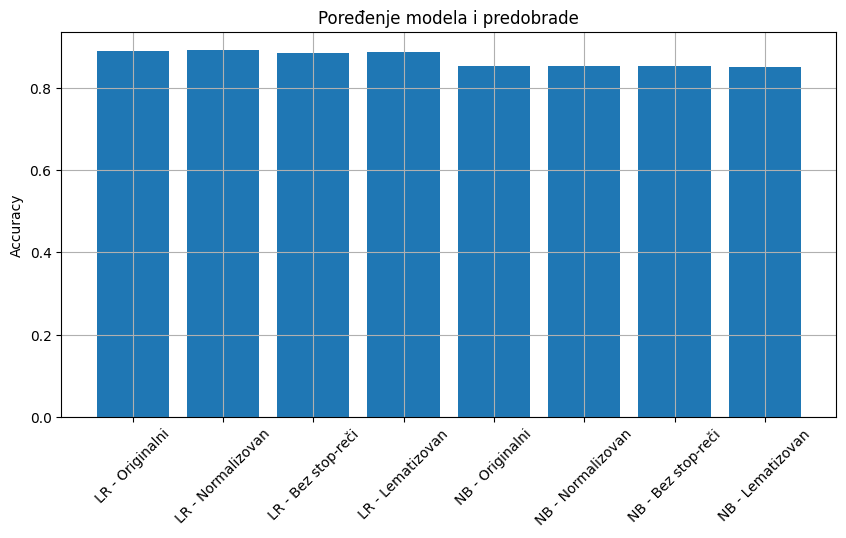

In [251]:
plt.figure()
plt.bar(results_df["Model"], results_df["Accuracy"])
plt.xticks(rotation=45)
plt.title("Poređenje modela i predobrade")
plt.ylabel("Accuracy")
plt.show()

Rezultati pokazuju da logistička regresija sa TF-IDF reprezentacijom postiže najbolje performanse. BoW je slabiji, ali pokazuje isti trend: normalizacija malo pomaže, dok agresivnija predobrada ne donosi dodatnu korist.
Naive Bayes model postiže slabije rezultate jer pretpostavlja nezavisnost karakteristika, što nije u potpunosti ispunjeno kod prirodnog jezika.
